## 1. 环境准备

导入必要的库并配置中文字体支持。

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib import rcParams

# ================== 全局环境配置 ==================
# 配置 matplotlib 使用中文字体
# 注意：run_jupyterlab.sh 已通过挂载 matplotlibrc 文件进行全局配置
# 这里再次配置是为了确保在非 Docker 环境（如本地直接运行）下也能正确显示中文
def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows标准/Docker挂载
        # Heiti TC: Mac标准
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        rcParams['font.sans-serif'] = fonts
        rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    except:
        pass

config_fonts()
print("环境配置完成，中文字体已设置。")

环境配置完成，中文字体已设置。


## 2. 决策树模型构建与可视化

本部分演示决策树算法在“是否玩高尔夫球”分类问题中的应用。

> **注意**：Scikit-learn 的 `DecisionTreeClassifier` 实现基于 **CART 算法**，构建的是**二叉树**，且默认使用**基尼系数 (Gini Impurity)** 作为分裂标准。本案例为了对应理论课程中的 ID3 算法示例，特意指定使用**信息熵**(Entropy)。

步骤如下：
1.  **数据创建**：手动创建包含“天气”和“湿度”特征的小型数据集。
2.  **数据预处理**：使用 `OneHotEncoder` 将分类文本特征转换为数值编码（独热编码）。
3.  **模型构建**：使用 `DecisionTreeClassifier`，设置 `criterion='entropy'`。
4.  **模型可视化**：通过 `plot_tree` 绘制决策树结构图（观察其二叉树结构），并使用 `export_text` 打印文本规则。
5.  **模型预测**：对新的天气和湿度组合进行预测，输出决策结果。

原始数据集:
天气 湿度 是否玩高尔夫球
晴天  高       否
晴天  高       否
晴天  高       是
多云  高       是
多云 正常       是
下雨  高       否
下雨 正常       是
下雨 正常       是
晴天 正常       是
晴天 正常       是
多云  高       是
多云 正常       是
下雨  高       否
下雨 正常       是


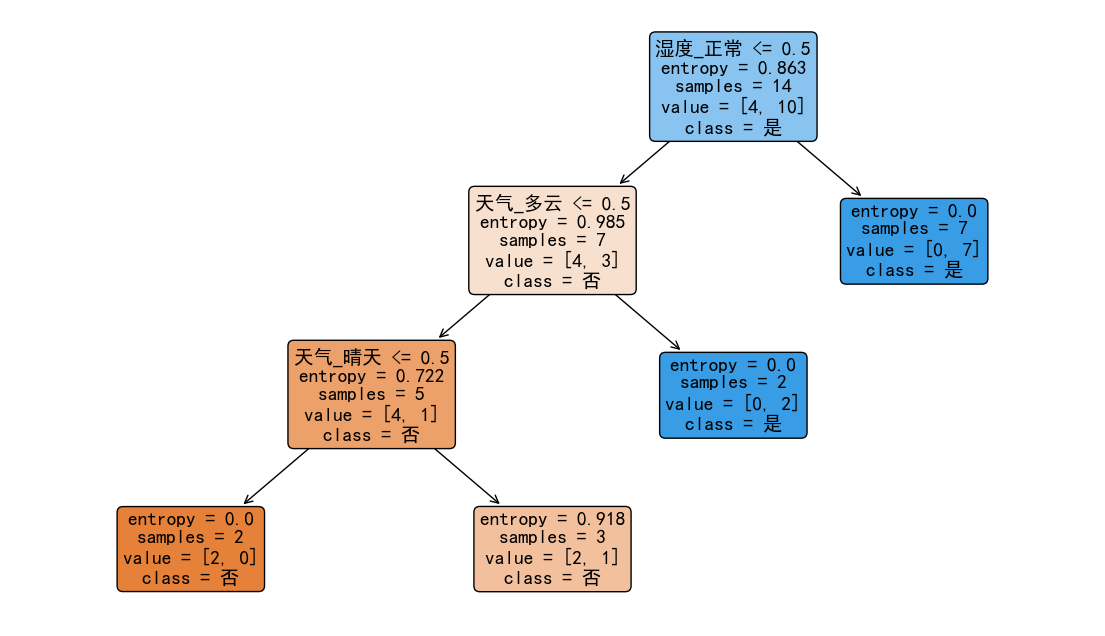

决策树文本结构:
|--- 湿度_正常 <= 0.50
|   |--- 天气_多云 <= 0.50
|   |   |--- 天气_晴天 <= 0.50
|   |   |   |--- class: 否
|   |   |--- 天气_晴天 >  0.50
|   |   |   |--- class: 否
|   |--- 天气_多云 >  0.50
|   |   |--- class: 是
|--- 湿度_正常 >  0.50
|   |--- class: 是

预测结果:
天气: 晴天, 湿度: 高 -> 否
天气: 晴天, 湿度: 正常 -> 是
天气: 多云, 湿度: 高 -> 是
天气: 多云, 湿度: 正常 -> 是
天气: 下雨, 湿度: 高 -> 否
天气: 下雨, 湿度: 正常 -> 是


In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.text import Text


# 创建数据集
data = {
    '天气': ['晴天', '晴天', '晴天', '多云', '多云', '下雨', '下雨', '下雨', '晴天', '晴天', '多云', '多云', '下雨', '下雨'],
    '湿度': ['高', '高', '高', '高', '正常', '高', '正常', '正常', '正常', '正常', '高', '正常', '高', '正常'],
    '是否玩高尔夫球': ['否', '否', '是', '是', '是', '否', '是', '是', '是', '是', '是', '是', '否', '是']
}

# 将数据转换为 DataFrame
df = pd.DataFrame(data)

print("原始数据集:")
print(df.to_string(index=False))

# 特征和目标变量
X = df[['天气', '湿度']]
y = df['是否玩高尔夫球']

# 使用 OneHotEncoder 直接处理
# handle_unknown='ignore' 防止预测时遇到训练集中未见的类别报错
# sparse_output=False 返回 numpy array 而不是 sparse matrix
try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    # 兼容旧版本 sklearn
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

X_encoded = encoder.fit_transform(X)
feature_names = encoder.get_feature_names_out(['天气', '湿度'])

# 转换为 DataFrame 以便查看和训练 (保持列名)
X_encoded_df = pd.DataFrame(X_encoded, columns=feature_names)

# 创建并训练模型
# criterion='entropy' 表示使用信息熵，默认是 'gini' (基尼系数)
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_encoded_df, y)

# --- 可视化 ---

# 打印决策树的结构
plt.figure(figsize=(14, 8))
tree_plot = plot_tree(
    clf,
    feature_names=feature_names,
    class_names=clf.classes_,
    filled=True,
    rounded=True
)

# 遍历图中的每个文本元素并调整字体大小
for t in plt.gca().get_children():
    if isinstance(t, Text):
        t.set_fontsize(14)
plt.show()

# 通过文本打印决策树
tree_rules = export_text(clf, feature_names=list(feature_names))
print("决策树文本结构:")
print(tree_rules)

# --- 预测 ---

# 预测新样本
new_samples_df = pd.DataFrame(
    [
        ['晴天', '高'],
        ['晴天', '正常'],
        ['多云', '高'],
        ['多云', '正常'],
        ['下雨', '高'],
        ['下雨', '正常'],
    ],
    columns=['天气', '湿度']
)

# 使用训练好的 encoder 进行转换
X_new_encoded = encoder.transform(new_samples_df)
X_new_encoded_df = pd.DataFrame(X_new_encoded, columns=feature_names)

# 进行预测
predictions = clf.predict(X_new_encoded_df)
print("预测结果:")
for (weather, humidity), prediction in zip(new_samples_df.values, predictions):
    print(f"天气: {weather}, 湿度: {humidity} -> {prediction}")


## 3. 进阶：决策树的过拟合与剪枝 (Iris 数据集)

决策树容易过拟合（Overfitting），即在训练集上表现很好，但在测试集上表现较差。我们可以通过**剪枝**（Pruning）来限制树的复杂度。

常用的预剪枝参数：
- `max_depth`: 树的最大深度。
- `min_samples_split`: 节点分裂所需的最小样本数。
- `min_samples_leaf`: 叶子节点所需的最小样本数。

下面使用经典的 Iris (鸢尾花) 数据集来演示不同深度对决策边界的影响。

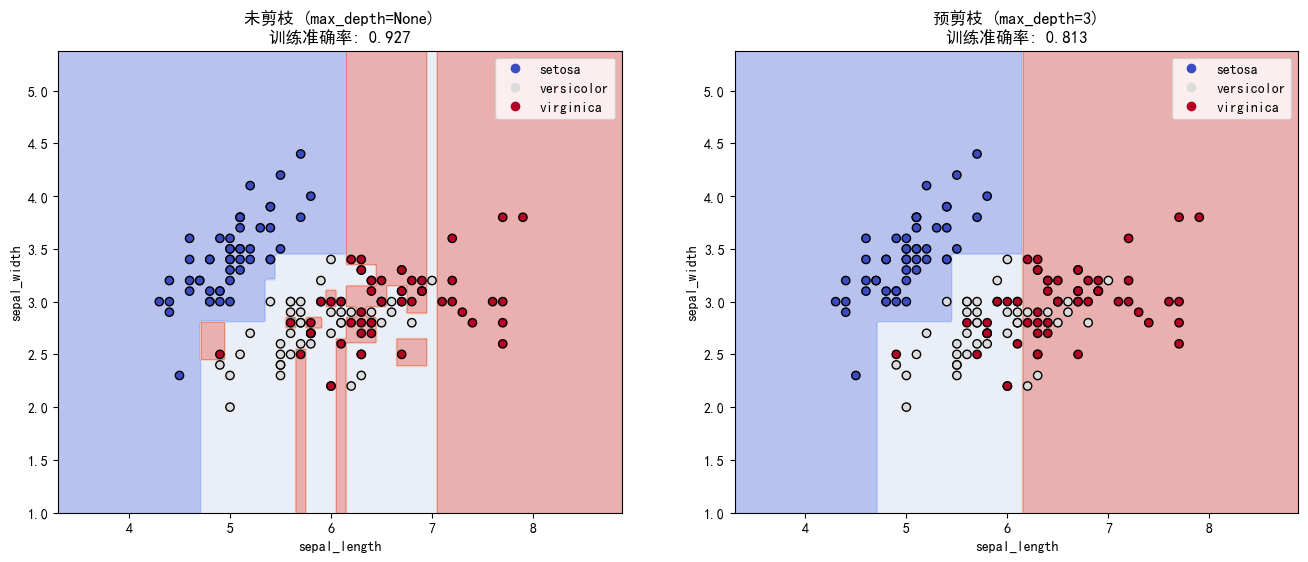

In [20]:
# from sklearn.datasets import load_iris
# from sklearn.inspection import DecisionBoundaryDisplay
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# 加载 Iris 数据集 (使用 seaborn 替代 sklearn.datasets)
try:
    iris_df = sns.load_dataset('iris')
except:
    # 如果 seaborn 加载失败，尝试从 URL 加载
    url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
    iris_df = pd.read_csv(url)

# 准备数据
# 为了方便可视化，我们只取前两个特征 (Sepal Length, Sepal Width)
# 注意：seaborn 数据集的列名通常是 'sepal_length', 'sepal_width'
feature_names = ['sepal_length', 'sepal_width']
target_name = 'species'

X_iris = iris_df[feature_names].values
y_iris = iris_df[target_name]

# 训练两个模型：一个不限制深度，一个限制深度
clf_deep = DecisionTreeClassifier(max_depth=None, random_state=42)
clf_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)

clf_deep.fit(X_iris, y_iris)
clf_pruned.fit(X_iris, y_iris)

# --- 自定义决策边界绘制函数 (替代 DecisionBoundaryDisplay) ---
def plot_decision_boundary(clf, X, y, ax, title):
    # 创建网格
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # 预测
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    
    # 将字符串标签转换为数值以便绘图
    # 获取所有类别
    classes = clf.classes_
    class_map = {c: i for i, c in enumerate(classes)}
    Z_num = np.array([class_map[label] for label in Z]).reshape(xx.shape)
    y_num = np.array([class_map[label] for label in y])
    
    # 绘图
    ax.contourf(xx, yy, Z_num, alpha=0.4, cmap=plt.cm.coolwarm)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y_num, edgecolors='k', cmap=plt.cm.coolwarm)
    
    ax.set_title(title)
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    # 添加图例
    handles, _ = scatter.legend_elements()
    ax.legend(handles, classes, loc="upper right")

# 可视化决策边界
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. 不限制深度
plot_decision_boundary(
    clf_deep, 
    X_iris, 
    y_iris, 
    ax[0], 
    f"未剪枝 (max_depth=None)\n训练准确率: {clf_deep.score(X_iris, y_iris):.3f}"
)

# 2. 限制深度 (max_depth=3)
plot_decision_boundary(
    clf_pruned, 
    X_iris, 
    y_iris, 
    ax[1], 
    f"预剪枝 (max_depth=3)\n训练准确率: {clf_pruned.score(X_iris, y_iris):.3f}"
)

plt.show()

# 解释：
# 左图可以看到复杂的决策边界，试图将每个点都正确分类（可能过拟合）。
# 右图边界更平滑，虽然训练准确率略低，但泛化能力通常更好。


## 4. 进阶：特征重要性

决策树可以计算每个特征的重要性（Feature Importance），这对于特征选择和理解数据非常有帮助。
重要性越高，说明该特征在树的分裂中起到的作用越大（即能带来更多的信息增益或基尼指数下降）。

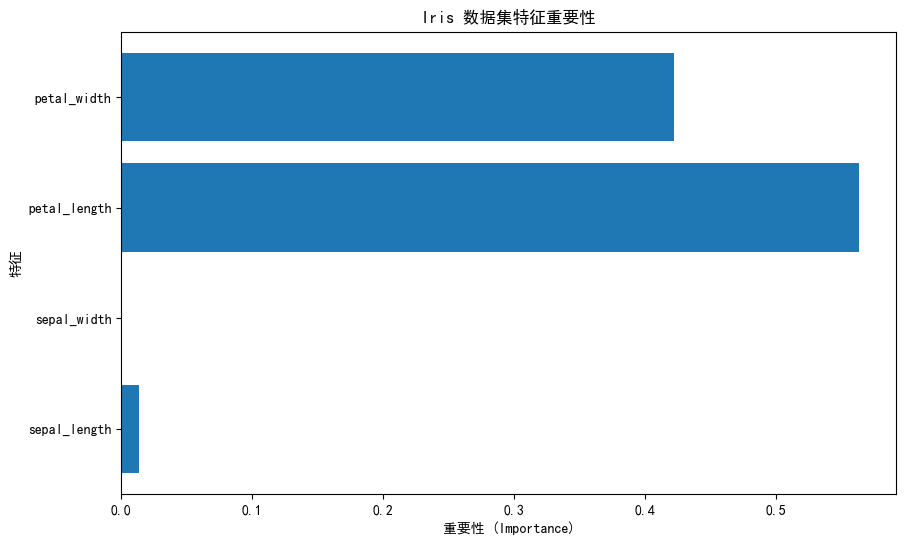

特征重要性数值:
sepal_length: 0.0133
sepal_width: 0.0000
petal_length: 0.5641
petal_width: 0.4226


In [21]:
# 准备所有特征数据 (基于之前加载的 iris_df)
# seaborn 数据集的特征列名通常如下
all_feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
target_name = 'species'

# 确保 iris_df 存在 (依赖于前面的单元格)
if 'iris_df' not in locals():
    # 如果前面单元格未运行，这里重新加载作为 fallback
    try:
        import seaborn as sns
        iris_df = sns.load_dataset('iris')
    except:
        import pandas as pd
        url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
        iris_df = pd.read_csv(url)

X_all = iris_df[all_feature_names].values
y_all = iris_df[target_name]

# 使用所有特征训练一个模型
clf_all = DecisionTreeClassifier(random_state=42)
clf_all.fit(X_all, y_all)

# 获取特征重要性
importances = clf_all.feature_importances_

# 可视化
plt.figure(figsize=(10, 6))
plt.barh(all_feature_names, importances)
plt.title("Iris 数据集特征重要性")
plt.xlabel("重要性 (Importance)")
plt.ylabel("特征")
plt.show()

print("特征重要性数值:")
for name, imp in zip(all_feature_names, importances):
    print(f"{name}: {imp:.4f}")
